# Data Pre-Processing + Model Training

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("/content/real_estate_120_records_filled.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (120, 9)


,town,address,property_type,bedrooms,bathrooms,parking,land_area_m2,sold_price_aud,sold_date
0,Blacktown,"15 Siebel Street, Blacktown",House,3,1,1,550.1,920000.0,2025-08-13
1,Blacktown,"26 Ellerston Glade, Blacktown",House,4,2,1,565.4,1035000.0,2025-08-14
2,Blacktown,"23/25-27 Fourth Avenue, Blacktown",Unit,2,1,1,112.0,440000.0,2025-08-15
3,Blacktown,"307/9-11 Swinson Road, Blacktown",Unit,2,2,1,85.0,585000.0,2025-08-15
4,Blacktown,"402/31 Carinya Street, Blacktown",Unit,2,2,1,98.0,441000.0,2025-08-15


In [3]:
# ============================================================
# 3. BASIC DATA CHECK
# ============================================================

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (120, 9)

Column names:
['town', 'address', 'property_type', 'bedrooms', 'bathrooms', 'parking', 'land_area_m2', 'sold_price_aud', 'sold_date']

Data types:
town               object
address            object
property_type      object
bedrooms            int64
bathrooms           int64
parking             int64
land_area_m2      float64
sold_price_aud    float64
sold_date          object
dtype: object

Missing values:
town              0
address           0
property_type     0
bedrooms          0
bathrooms         0
parking           0
land_area_m2      0
sold_price_aud    0
sold_date         0
dtype: int64

Duplicate rows: 0


In [4]:
# ============================================================
# 4. DATE FEATURE ENGINEERING
# ============================================================

df["sold_date"] = pd.to_datetime(df["sold_date"], errors="coerce")

df["sold_year"] = df["sold_date"].dt.year
df["sold_month"] = df["sold_date"].dt.month

print(df[["sold_date", "sold_year", "sold_month"]].head())

   sold_date  sold_year  sold_month
0 2025-08-13       2025           8
1 2025-08-14       2025           8
2 2025-08-15       2025           8
3 2025-08-15       2025           8
4 2025-08-15       2025           8


In [5]:
# ============================================================
# 5. DEFINE FEATURES AND TARGET
# ============================================================

# Target variable
y = df["sold_price_aud"]

# Input features
X = df.drop(columns=[
    "sold_price_aud",
    "address",
    "sold_date"
])

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['town', 'property_type', 'bedrooms', 'bathrooms', 'parking', 'land_area_m2', 'sold_year', 'sold_month']

Target:
sold_price_aud

X shape: (120, 8)
y shape: (120,)


In [6]:
# ============================================================
# 6. IDENTIFY FEATURE TYPES
# ============================================================

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['town', 'property_type']

Numerical features:
['bedrooms', 'bathrooms', 'parking', 'land_area_m2', 'sold_year', 'sold_month']


In [7]:
# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target:", y_train.shape)
print("Testing target:", y_test.shape)

Training set: (96, 8)
Testing set: (24, 8)

Training target: (96,)
Testing target: (24,)


In [8]:
# ============================================================
# 8. PREPROCESSING PIPELINE
# ============================================================

# Numerical preprocessing
numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Combine both
preprocessor = ColumnTransformer([
    ("num", numeric_preprocessor, numerical_features),
    ("cat", categorical_preprocessor, categorical_features)
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


# Model Training
-> Linear Regression — simple baseline and highly interpretable.

-> Random Forest Regressor — captures nonlinear relationships and interactions.

-> Gradient Boosting Regressor — sequential ensemble model that can capture complex patterns.

Important setup

The preprocessed dataset is called df and:

sold_price_aud = target
town, property_type = categorical features already encoded
numerical features are already cleaned
sold_year and sold_month are available if you created them

In [9]:
# ============================================================
# 9. CREATE THREE REGRESSION MODELS
# ============================================================

# Model 1: Linear Regression
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])


# Model 2: Random Forest
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ))
])


# Model 3: Gradient Boosting
gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])


models = {
    "Linear Regression": linear_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

print("Three models created:")
for name in models:
    print("-", name)

Three models created:
- Linear Regression
- Random Forest
- Gradient Boosting


In [10]:
# ============================================================
# 10. 5-FOLD CROSS-VALIDATION
# ============================================================

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        return_train_score=True,
        error_score="raise"
    )

    cv_results.append({
        "Model": name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R²": scores["test_R2"].mean(),
        "Train R²": scores["train_R2"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

print("5-Fold Cross-Validation Results:")
display(cv_results_df.round(2))

5-Fold Cross-Validation Results:


,Model,CV MAE,CV RMSE,CV R²,Train R²
0,Linear Regression,952850.27,1258263.91,-0.30,0.22
1,Random Forest,938237.18,1403685.50,-0.75,0.74
2,Gradient Boosting,994498.67,1496886.25,-1.02,0.75


In [11]:
# ============================================================
# 11. TRAIN THE MODELS
# ============================================================

trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    trained_models[name] = model

    print(f"{name} trained successfully.")

Linear Regression trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


In [12]:
# ============================================================
# 12. PREDICT ON TEST SET
# ============================================================

predictions = {}

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    predictions[name] = y_pred

    print(f"{name}: predictions generated.")

Linear Regression: predictions generated.
Random Forest: predictions generated.
Gradient Boosting: predictions generated.


# Result Evaluation

In [13]:
# ============================================================
# 13. TEST SET EVALUATION
# ============================================================

test_results = []

for name, y_pred in predictions.items():

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    test_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

test_results_df = pd.DataFrame(test_results)

print("Test Set Results:")
display(test_results_df.round(2))

Test Set Results:


,Model,MAE,RMSE,R²
0,Linear Regression,770086.72,888115.75,0.04
1,Random Forest,617892.11,818296.26,0.18
2,Gradient Boosting,788764.04,1038454.81,-0.32


In [14]:
# ============================================================
# 14. COMBINED MODEL COMPARISON
# ============================================================

comparison = cv_results_df.merge(
    test_results_df,
    on="Model"
)

display(comparison.round(2))

,Model,CV MAE,CV RMSE,CV R²,Train R²,MAE,RMSE,R²
0,Linear Regression,952850.27,1258263.91,-0.30,0.22,770086.72,888115.75,0.04
1,Random Forest,938237.18,1403685.50,-0.75,0.74,617892.11,818296.26,0.18
2,Gradient Boosting,994498.67,1496886.25,-1.02,0.75,788764.04,1038454.81,-0.32


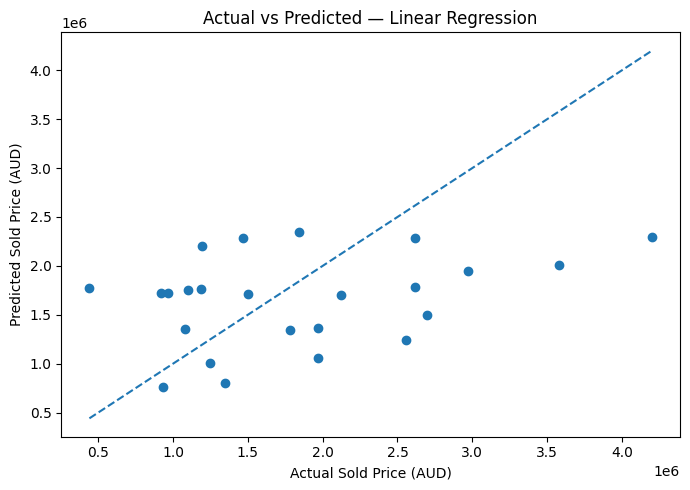

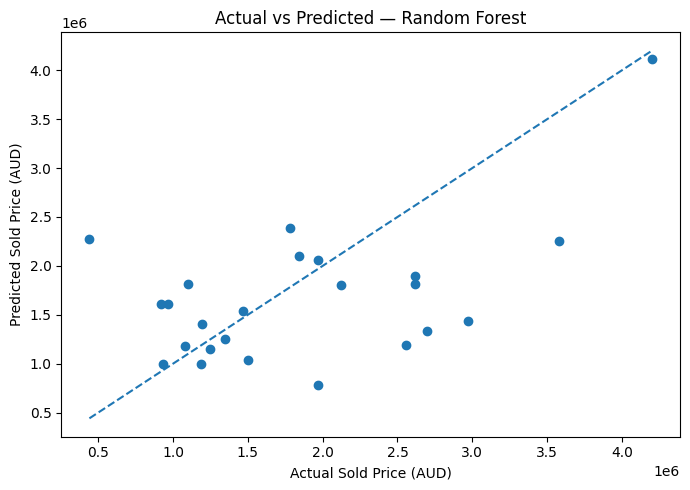

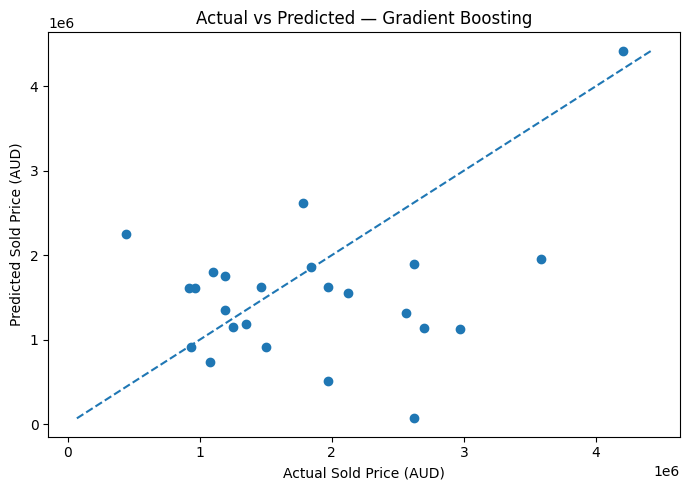

In [15]:
# ============================================================
# 15. ACTUAL VS PREDICTED
# ============================================================

for name, y_pred in predictions.items():

    plt.figure(figsize=(7, 5))

    plt.scatter(y_test, y_pred)

    # Perfect prediction line
    minimum = min(y_test.min(), y_pred.min())
    maximum = max(y_test.max(), y_pred.max())

    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )

    plt.xlabel("Actual Sold Price (AUD)")
    plt.ylabel("Predicted Sold Price (AUD)")
    plt.title(f"Actual vs Predicted — {name}")

    plt.tight_layout()
    plt.show()

# Check for Overfitting & Underfitting

In [16]:
# ============================================================
# 16. OVERFITTING CHECK
# ============================================================

diagnosis = []

for name, model in trained_models.items():

    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    train_r2 = r2_score(
        y_train,
        train_prediction
    )

    test_r2 = r2_score(
        y_test,
        test_prediction
    )

    diagnosis.append({
        "Model": name,
        "Train R²": train_r2,
        "Test R²": test_r2,
        "R² Gap": train_r2 - test_r2
    })

diagnosis_df = pd.DataFrame(diagnosis)

display(diagnosis_df.round(3))

,Model,Train R²,Test R²,R² Gap
0,Linear Regression,0.186,0.037,0.149
1,Random Forest,0.691,0.182,0.509
2,Gradient Boosting,0.659,-0.317,0.976


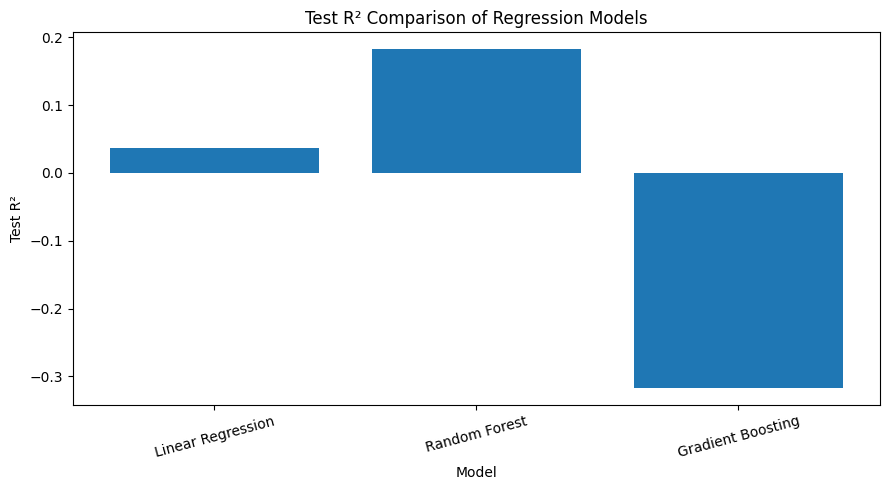

In [17]:
# ============================================================
# 17. MODEL COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    test_results_df["Model"],
    test_results_df["R²"]
)

plt.ylabel("Test R²")
plt.xlabel("Model")
plt.title("Test R² Comparison of Regression Models")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()